In [ ]:
pip install torch transformers peft trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 51.5 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 39.9 MB/s eta 0:00:00


In [ ]:
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer

# Hyperparameter configurations

Model that is fine tuned is mistral AI. Mistral AI is known for beeing efficient and powerful. Other model to consider aree Llama-3 (computationally expensive), Phi-3

In [ ]:
# ==========================================
# 1. CONFIGURATION & HYPERPARAMETERS
# ==========================================
MODEL_ID = "google/gemma-4-12b-it"  # Replace with your choice (e.g., Llama-3, Phi-3)
OUTPUT_DIR = "./fine_tuned_llm"

# LoRA Hyperparameters
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
TARGET_MODULES = "all-linear"

# Training Hyperparameters
BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 4
LEARNING_RATE = 2e-4
MAX_STEPS = 100  # Adjust based on dataset size (or use num_train_epochs)

###LoRA Hyperparameters (for QLoRA fine-tuning):


LORA_R = 16 (Rank r): This is one of the most crucial LoRA parameters. It determines the rank of the low-rank matrices that are added to the pre-trained model's weight matrices. A higher r allows for more expressiveness and capacity to learn new information, but also increases the number of trainable parameters and VRAM usage. A lower r means fewer trainable parameters, making the fine-tuning more efficient but potentially less effective at capturing complex new patterns.

LORA_ALPHA = 32 (α): This parameter scales the learned low-rank updates. It's often set to 2 * LORA_R or a similar multiple. A higher alpha means the LoRA layers have a stronger influence on the original weights. It essentially controls the magnitude of the updates applied by the LoRA adapters.

LORA_DROPOUT = 0.05: This is a standard dropout rate applied to the LoRA layers during training. Dropout is a regularization technique that randomly sets a fraction of input units to 0 at each update during training, which helps prevent overfitting by encouraging the model to learn more robust features.

TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]: This specifies which parts (modules) of the pre-trained transformer model will have LoRA layers attached to them. In Large Language Models, q_proj, k_proj, v_proj (query, key, and value projection layers in attention mechanisms) and o_proj (output projection) are common targets. gate_proj, up_proj, down_proj refer to the feed-forward network's layers.

By selectively applying LoRA to these critical modules, you can efficiently fine-tune the model without modifying all its original weights.

###Training Hyperparameters:


BATCH_SIZE = 4 (per_device_train_batch_size): This is the number of training examples processed at once on each GPU. Smaller batch sizes often lead to better generalization but longer training times. For QLoRA, which is memory-efficient, you can often use larger batch sizes than full fine-tuning.

GRADIENT_ACCUMULATION_STEPS = 4: When memory is a constraint (even with QLoRA), you can simulate a larger effective batch size by accumulating gradients over several smaller batches. Here, an effective batch size of BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS = 4 * 4 = 16 is used. The model weights are updated only after processing GRADIENT_ACCUMULATION_STEPS batches.

LEARNING_RATE = 2e-4: This determines the step size at each iteration while moving towards a minimum of the loss function. It's a critical hyperparameter; too high, and the model might overshoot the minimum; too low, and training could be very slow or get stuck in a local minimum. For QLoRA, a slightly lower learning rate than full fine-tuning is often recommended.

MAX_STEPS = 100: This defines the total number of update steps (batches after gradient accumulation) the trainer will perform during the fine-tuning process. You mentioned adjusting this based on dataset size or using num_train_epochs, which is a good practice. For a small dataset or initial experimentation, 100 steps is a reasonable starting point.

In [ ]:
from google.colab import userdata
import os

# Access your Hugging Face token from Colab Secrets
hf_token = userdata.get('HF_TOKEN')

# Set it as an environment variable, which many Hugging Face libraries will automatically pick up
os.environ['HF_TOKEN'] = hf_token

print("Hugging Face token loaded and set as environment variable.")

Hugging Face token loaded and set as environment variable.


# Loading dataset

dataset derived from hugging face is tatsu-lab/alpaca which has been surpassed with more recent dataseet such as databricks/databricks-dolly-15k and OpenAssistant/oasst1.

Production level performance involve using more comprehensive dataset that has a higher quality (less noisy), greater diversity (wider range of instruction) and larger scale.

In [ ]:
# Load tokenizer before using it in format_prompts
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.padding_side = "left" # Essential for causal LLM training stability

if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

config.json:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/17.5k [00:00<?, ?B/s]

In [ ]:
# ==========================================
# 2. LOAD DATASET
# ==========================================
# Loading a sample instruction dataset from Hugging Face
# Ensure your data has a column with formatted text, or use a formatting function
train_dataset = load_dataset("HuggingFaceH4/ultrachat_200k", split="train_sft[:1500]") # Using first 1000 rows for demonstration
eval_dataset = load_dataset("HuggingFaceH4/ultrachat_200k", split="train_sft[1200:1500]") # Using the last 300 rows


def format_prompts(batch):
    formatted_texts = []
    for conversation in batch['messages']:
        text = ""
        for turn in conversation:
            role = turn.get("role", "")
            content = turn.get("content", "")
            if role == "user":
                text += f"### Instruction:\n{content}\n\n"
            elif role == "assistant":
                text += f"### Response:\n{content}\n\n"
        formatted_texts.append(text.strip())
    return {"text": formatted_texts}

# Key fix: remove_columns drops 'prompt', 'prompt_id', 'messages'
# leaving ONLY the 'text' column so TRL doesn't get confused
train_dataset = train_dataset.map(format_prompts, batched=True, remove_columns=train_dataset.column_names)
eval_dataset  = eval_dataset.map(format_prompts,  batched=True, remove_columns=eval_dataset.column_names)

print("Columns:", train_dataset.column_names)  # should show: ['text']
print(train_dataset[0]["text"][:300])

README.md:   0%|          | 0.00/3.90k [00:00<?, ?B/s]

data/train_sft-00000-of-00003-a3ecf92756(…):   0%|          | 0.00/244M [00:00<?, ?B/s]

data/train_sft-00001-of-00003-0a1804bcb6(…):   0%|          | 0.00/244M [00:00<?, ?B/s]

data/train_sft-00002-of-00003-ee46ed25cf(…):   0%|          | 0.00/244M [00:00<?, ?B/s]

data/test_sft-00000-of-00001-f7dfac4afe5(…):   0%|          | 0.00/81.2M [00:00<?, ?B/s]

...

Generating train_gen split:   0%|          | 0/256032 [00:00<?, ? examples/s]

Generating test_gen split:   0%|          | 0/28304 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Columns: ['text']
### Instruction:
These instructions apply to section-based themes (Responsive 6.0+, Retina 4.0+, Parallax 3.0+ Turbo 2.0+, Mobilia 5.0+). What theme version am I using?
On your Collections pages & Featured Collections sections, you can easily show the secondary image of a product on hover by enablin


# Loading Tokenizer

In [ ]:
# ==========================================
# 3. LOAD TOKENIZER AND QUANTIZED MODEL
# ==========================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.padding_side = "left" # Essential for causal LLM training stability

if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

# Configure 4-bit quantization for QLoRA
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16, # Use float16 if your GPU doesn't support bfloat16
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto", # Automatically distributes layers across available GPUs
)

# Prepare model for k-bit training (handles gradient checkpointing and freezing)
model = prepare_model_for_kbit_training(model)


model.safetensors:   0%|          | 0.00/23.9G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/677 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/260 [00:00<?, ?B/s]

# Configuring LORA

In [ ]:
# ==========================================
# 4. CONFIGURAING LoRA (PEFT)
# ==========================================
peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=TARGET_MODULES,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)


LoRA adapter saveed from training cannot bee loaded onto Gemma4ForConditionalGeneration - the adapter was trained on a model with standard torch.nn.Linear layers but Gemma 4 uses Gemma4ClippableLinear which PEFT doesnt support

# Setup training arguments

In [ ]:
print(train_dataset.column_names)

['text']


In [ ]:
print(train_dataset[0]["text"])

### Instruction:
These instructions apply to section-based themes (Responsive 6.0+, Retina 4.0+, Parallax 3.0+ Turbo 2.0+, Mobilia 5.0+). What theme version am I using?
On your Collections pages & Featured Collections sections, you can easily show the secondary image of a product on hover by enabling one of the theme's built-in settings!
Your Collection pages & Featured Collections sections will now display the secondary product image just by hovering over that product image thumbnail.
Does this feature apply to all sections of the theme or just specific ones as listed in the text material?

### Response:
This feature only applies to Collection pages and Featured Collections sections of the section-based themes listed in the text material.

### Instruction:
Can you guide me through the process of enabling the secondary image hover feature on my Collection pages and Featured Collections sections?

### Response:
Sure, here are the steps to enable the secondary image hover feature on your

In [ ]:
print("Train columns:", train_dataset.column_names)
print("First example:", train_dataset[0])

Train columns: ['text']
First example: {'text': "### Instruction:\nThese instructions apply to section-based themes (Responsive 6.0+, Retina 4.0+, Parallax 3.0+ Turbo 2.0+, Mobilia 5.0+). What theme version am I using?\nOn your Collections pages & Featured Collections sections, you can easily show the secondary image of a product on hover by enabling one of the theme's built-in settings!\nYour Collection pages & Featured Collections sections will now display the secondary product image just by hovering over that product image thumbnail.\nDoes this feature apply to all sections of the theme or just specific ones as listed in the text material?\n\n### Response:\nThis feature only applies to Collection pages and Featured Collections sections of the section-based themes listed in the text material.\n\n### Instruction:\nCan you guide me through the process of enabling the secondary image hover feature on my Collection pages and Featured Collections sections?\n\n### Response:\nSure, here are

In [ ]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    logging_steps=10,
    max_steps=MAX_STEPS,
    optim="paged_adamw_8bit",
    bf16=True,
    save_strategy="steps",
    save_steps=50,
    eval_strategy="steps",
    eval_steps=50,
    dataset_text_field="text",   # valid in TRL 1.6.0
    max_length=1024,             # correct name in TRL 1.6.0 (not max_seq_length)
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    peft_config=peft_config,
    processing_class=tokenizer,  # correct name in TRL 1.6.0 (not tokenizer=)
    args=training_args,
)

/tmp/ipykernel_1484/908874293.py:3: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  training_args = SFTConfig(


Adding EOS to train dataset:   0%|          | 0/1500 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1500 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/300 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/300 [00:00<?, ? examples/s]

In [ ]:
import trl, inspect
from trl import SFTConfig
print("TRL version:", trl.__version__)
params = [p for p in inspect.signature(SFTConfig.__init__).parameters]
print("SFTConfig params:", params)

TRL version: 1.6.0
SFTConfig params: ['self', 'output_dir', 'per_device_train_batch_size', 'num_train_epochs', 'max_steps', 'learning_rate', 'lr_scheduler_type', 'lr_scheduler_kwargs', 'warmup_steps', 'optim', 'optim_args', 'weight_decay', 'adam_beta1', 'adam_beta2', 'adam_epsilon', 'optim_target_modules', 'gradient_accumulation_steps', 'average_tokens_across_devices', 'max_grad_norm', 'label_smoothing_factor', 'bf16', 'fp16', 'bf16_full_eval', 'fp16_full_eval', 'tf32', 'gradient_checkpointing', 'gradient_checkpointing_kwargs', 'torch_compile', 'torch_compile_backend', 'torch_compile_mode', 'use_liger_kernel', 'liger_kernel_config', 'use_cache', 'neftune_noise_alpha', 'torch_empty_cache_steps', 'auto_find_batch_size', 'logging_strategy', 'logging_steps', 'logging_first_step', 'log_on_each_node', 'logging_nan_inf_filter', 'include_num_input_tokens_seen', 'log_level', 'log_level_replica', 'disable_tqdm', 'report_to', 'run_name', 'project', 'trackio_space_id', 'trackio_bucket_id', 'tracki

In [ ]:
print("Columns:", train_dataset.column_names)
print("First example text:", train_dataset[0]["text"][:200])

Columns: ['text']
First example text: ### Instruction:
These instructions apply to section-based themes (Responsive 6.0+, Retina 4.0+, Parallax 3.0+ Turbo 2.0+, Mobilia 5.0+). What theme version am I using?
On your Collections pages & Fea


# Execute training and save adapters

In [ ]:
# ==========================================
# 6. EXECUTE TRAINING AND SAVE ADAPTERS
# ==========================================
print("Starting fine-tuning...")
trainer.train()

# Save the trained LoRA adapter weights (not the entire base model)
trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"Training complete! Adapter saved to {OUTPUT_DIR}")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.


Starting fine-tuning...


Step,Training Loss,Validation Loss,Entropy,Mean Token Accuracy,Num Tokens
50,1.539820,1.418182,1.494069,0.654186,708270.000000
100,1.280706,1.271911,1.292827,0.670239,1418577.000000


Training complete! Adapter saved to ./fine_tuned_llm


### Plotting Training Metrics

Let's visualize the training loss over the fine-tuning steps to see the model's learning progress.

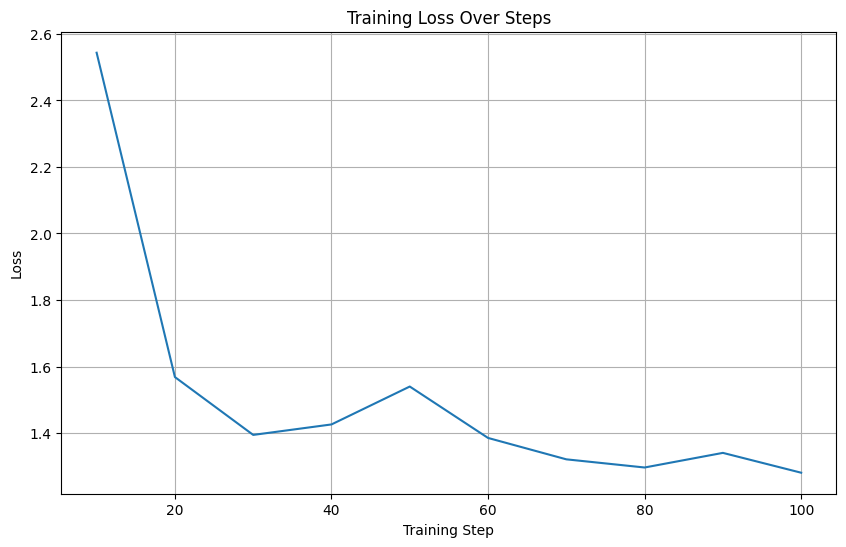

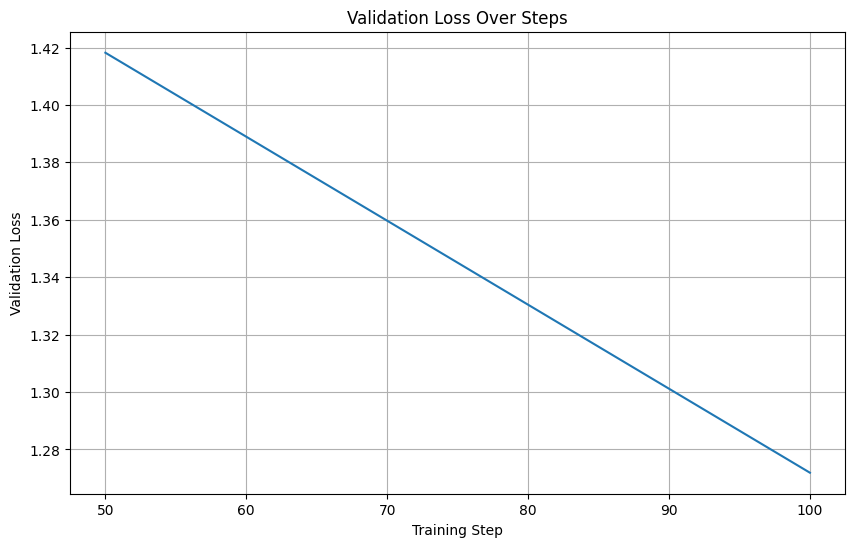

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract training history from the trainer
log_history = trainer.state.log_history

# Convert to a DataFrame for easier plotting
logs_df = pd.DataFrame(log_history)

# Filter for training loss (usually denoted as 'loss' or 'train_loss')
# 'loss' is typically the training loss reported at each logging step
# 'eval_loss' would be present if evaluation_strategy was set to 'steps' or 'epoch'

train_loss_data = logs_df.dropna(subset=['loss'])

if not train_loss_data.empty:
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=train_loss_data, x='step', y='loss')
    plt.title('Training Loss Over Steps')
    plt.xlabel('Training Step')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()
else:
    print("No training loss data found in the trainer's log history.")

# If evaluation_strategy was enabled and had eval_loss:
eval_loss_data = logs_df.dropna(subset=['eval_loss'])

if not eval_loss_data.empty:
     plt.figure(figsize=(10, 6))
     sns.lineplot(data=eval_loss_data, x='step', y='eval_loss')
     plt.title('Validation Loss Over Steps')
     plt.xlabel('Training Step')
     plt.ylabel('Validation Loss')
     plt.grid(True)
     plt.show()
else:
     print("No validation loss data found in the trainer's log history.")

#Why do we fine-tune a model?

We fine-tune a pre-trained model primarily to adapt it to a specific task or dataset that differs from the one it was originally trained on.

Large Language Models (LLMs) like (Mistral-7B) are typically trained on vast amounts of general text data, making them proficient at understanding and generating human-like text.

However, they might lack specialized knowledge, jargon, or stylistic preferences required for a particular domain (e.g., medical texts, legal documents, customer support) or a specific application (e.g., summarization, translation, specific question answering).

Fine-tuning allows the model to learn these specific nuances while retaining the broad understanding it gained during its initial pre-training, effectively tailoring its capabilities to your exact needs.

#Advantages and Disadvantages of Fine-tuning a Model:

###Advantages:

Improved Performance on Specific Tasks: Fine-tuning makes the model highly effective for your target task or domain, often outperforming general-purpose models.

Less Data Required (vs. Training from Scratch): You don't need a massive dataset like the one used for initial pre-training. A relatively smaller, high-quality, task-specific dataset is often sufficient.

Faster Training: Since the model already has a strong foundation, fine-tuning converges much faster than training a model from scratch.


Cost-Effective: Less data and faster training translate to lower computational costs.


Leverages Pre-trained Knowledge: The model benefits from the vast general knowledge acquired during pre-training, making it robust and less prone to overfitting on small datasets.


Transfer Learning: It's an excellent example of transfer learning, where knowledge gained from one task (general language understanding) is transferred to improve performance on another (specific domain task).


###Disadvantages:

Requires Labeled Data: You still need a labeled dataset specific to your task, which can sometimes be expensive or time-consuming to create.


Catastrophic Forgetting: If fine-tuned improperly or on very different data, the model might 'forget' some of its general knowledge. Techniques like LoRA (which you're using) help mitigate this by not directly modifying the original weights.


Computational Resources: While less demanding than training from scratch, fine-tuning LLMs still requires significant computational resources (GPUs, VRAM), though methods like QLoRA reduce this burden.


Hyperparameter Tuning: Finding the optimal hyperparameters (like the LORA_R, LORA_ALPHA, LEARNING_RATE, BATCH_SIZE you configured) can still require experimentation.


Model Bias: If the fine-tuning dataset contains biases, the model can learn and even amplify these biases.


###How can I apply my fine-tuned model to a dataset?

After fine-tuning with QLoRA and saving the adapter weights (as you've done in your notebook), you typically apply the model in a few steps:

Load the Base Model: Load the original pre-trained model (e.g., mistralai/Mistral-7B-v0.1) in its quantized form.


Load the PEFT Adapter: Load your saved LoRA adapter weights (./fine_tuned_llm) and attach them to the base model.


Load the Tokenizer: Load the tokenizer you used during fine-tuning (also saved to ./fine_tuned_llm).


Merge and Save (Optional but Recommended for Deployment): For easier deployment, you can merge the LoRA adapter weights back into the base model. This creates a single, larger model that behaves like the fine-tuned version without needing the PEFT library at inference time. This merged model can then be saved as a standard Hugging Face model.


Inference: Once the fine-tuned model (or the merged model) is loaded, you can use it to generate responses for new inputs from your dataset. You'll typically tokenize your input, pass it to the model for generation, and then decode the output tokens back into human-readable text.

### Download the fine_tuned_llm folder

In [ ]:
import os
from google.colab import files

# Define the output directory
OUTPUT_DIR = "./fine_tuned_llm"

# Create a zip archive of the folder
zip_filename = f"{os.path.basename(OUTPUT_DIR)}.zip"
!zip -r "{zip_filename}" "{OUTPUT_DIR}"

# Download the zip file to your local machine
files.download(zip_filename)


  adding: fine_tuned_llm/ (stored 0%)
  adding: fine_tuned_llm/chat_template.jinja (deflated 82%)
  adding: fine_tuned_llm/tokenizer_config.json (deflated 73%)
  adding: fine_tuned_llm/README.md (deflated 43%)
  adding: fine_tuned_llm/checkpoint-50/ (stored 0%)
  adding: fine_tuned_llm/checkpoint-50/chat_template.jinja (deflated 82%)
  adding: fine_tuned_llm/checkpoint-50/tokenizer_config.json (deflated 73%)
  adding: fine_tuned_llm/checkpoint-50/scheduler.pt (deflated 62%)
  adding: fine_tuned_llm/checkpoint-50/rng_state.pth (deflated 26%)
  adding: fine_tuned_llm/checkpoint-50/README.md (deflated 65%)
  adding: fine_tuned_llm/checkpoint-50/tokenizer.json (deflated 83%)
  adding: fine_tuned_llm/checkpoint-50/trainer_state.json (deflated 67%)
  adding: fine_tuned_llm/checkpoint-50/optimizer.pt (deflated 11%)
  adding: fine_tuned_llm/checkpoint-50/training_args.bin (deflated 53%)
  adding: fine_tuned_llm/checkpoint-50/adapter_config.json (deflated 59%)
  adding: fine_tuned_llm/checkpoin

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Alternatively, save to Google Drive for permanent storage

If you prefer to save it directly to Google Drive, you can mount your Drive and copy the folder there. This ensures persistence even if your Colab session ends.

In [ ]:
from google.colab import drive
import shutil

# Mount Google Drive
drive.mount('/content/drive')

# Define the output directory and the destination path in Google Drive
OUTPUT_DIR = "./fine_tuned_llm"
DRIVE_PATH = "/content/drive/MyDrive/FineTunedModels"

# Create the destination directory in Drive if it doesn't exist
os.makedirs(DRIVE_PATH, exist_ok=True)

# Copy the fine_tuned_llm folder to Google Drive
shutil.copytree(OUTPUT_DIR, os.path.join(DRIVE_PATH, os.path.basename(OUTPUT_DIR)), dirs_exist_ok=True)

print(f"Folder '{OUTPUT_DIR}' successfully copied to '{DRIVE_PATH}'")


Mounted at /content/drive
Folder './fine_tuned_llm' successfully copied to '/content/drive/MyDrive/FineTunedModels'


## Using the Fine-tuned Model for Inference (Chatbot Integration)

First, we need to load the base model and the fine-tuned adapter. We'll use the same `MODEL_ID` and `OUTPUT_DIR` as before.

In [ ]:
'''import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

# Configuration (from earlier cells)
MODEL_ID = "google/gemma-4-12b-it"
OUTPUT_DIR = "./fine_tuned_llm"

# 1. Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(OUTPUT_DIR)

# 2. Configure 4-bit quantization (same as during training)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# 3. Load the base model with quantization
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)

# 4. Load the fine-tuned PEFT (LoRA) adapter
model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)

print("Base model and fine-tuned adapter loaded successfully!")'''


'import torch\nfrom transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig\nfrom peft import PeftModel\n\n# Configuration (from earlier cells)\nMODEL_ID = "google/gemma-4-12b-it"\nOUTPUT_DIR = "./fine_tuned_llm"\n\n# 1. Load the tokenizer\ntokenizer = AutoTokenizer.from_pretrained(OUTPUT_DIR)\n\n# 2. Configure 4-bit quantization (same as during training)\nbnb_config = BitsAndBytesConfig(\n    load_in_4bit=True,\n    bnb_4bit_quant_type="nf4",\n    bnb_4bit_compute_dtype=torch.bfloat16,\n    bnb_4bit_use_double_quant=True,\n)\n\n# 3. Load the base model with quantization\nbase_model = AutoModelForCausalLM.from_pretrained(\n    MODEL_ID,\n    quantization_config=bnb_config,\n    device_map="auto",\n)\n\n# 4. Load the fine-tuned PEFT (LoRA) adapter\nmodel = PeftModel.from_pretrained(base_model, OUTPUT_DIR)\n\nprint("Base model and fine-tuned adapter loaded successfully!")'

Now that the model and tokenizer are loaded, we can define a function to generate responses. This function will take a prompt, format it, tokenize it, and then use the model to generate a sequence of tokens, which will then be decoded back into human-readable text.

In [ ]:
'''def generate_response(prompt: str, max_new_tokens: int = 100) -> str:
    # Format the prompt according to the Dolly-15k instruction format (simplified)
    formatted_prompt = f"### Instruction:\n{prompt}\n\n### Response:\n"

    # Tokenize the input prompt
    input_ids = tokenizer(formatted_prompt, return_tensors="pt").input_ids.cuda()

    # Generate a response
    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=True, # Enable sampling for more diverse responses
            top_p=0.9,      # Nucleus sampling
            temperature=0.7, # Controls randomness
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    # Decode the generated tokens
    response = tokenizer.decode(outputs[0][len(input_ids[0]):], skip_special_tokens=True)
    return response.strip()


# Example Usage:
print("\n--- Testing the chatbot with an example prompt ---")
user_query = "Explain the concept of quantum entanglement in simple terms."
chatbot_response = generate_response(user_query)
print(f"User: {user_query}")
print(f"Chatbot: {chatbot_response}")

user_query_2 = "What is the capital of France?"
chatbot_response_2 = generate_response(user_query_2)
print(f"\nUser: {user_query_2}")
print(f"Chatbot: {chatbot_response_2}")'''


'def generate_response(prompt: str, max_new_tokens: int = 100) -> str:\n    # Format the prompt according to the Dolly-15k instruction format (simplified)\n    formatted_prompt = f"### Instruction:\n{prompt}\n\n### Response:\n"\n\n    # Tokenize the input prompt\n    input_ids = tokenizer(formatted_prompt, return_tensors="pt").input_ids.cuda()\n\n    # Generate a response\n    with torch.no_grad():\n        outputs = model.generate(\n            input_ids=input_ids,\n            max_new_tokens=max_new_tokens,\n            do_sample=True, # Enable sampling for more diverse responses\n            top_p=0.9,      # Nucleus sampling\n            temperature=0.7, # Controls randomness\n            pad_token_id=tokenizer.pad_token_id,\n            eos_token_id=tokenizer.eos_token_id,\n        )\n\n    # Decode the generated tokens\n    response = tokenizer.decode(outputs[0][len(input_ids[0]):], skip_special_tokens=True)\n    return response.strip()\n\n\n# Example Usage:\nprint("\n--- Testing

## Loading the Fine-tuned Model from Google Drive in a New Notebook

This section demonstrates how you would load your previously saved fine-tuned model from Google Drive into a *new* Colab notebook for inference with your chatbot.

### Step 1: Install Required Libraries

First, you'll need to install the necessary libraries (`transformers`, `peft`, `bitsandbytes`, `accelerate`, `trl`, `torch`) in your new Colab session.

In [ ]:
!pip install -q -U transformers peft bitsandbytes accelerate trl torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 132.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### Step 2: Mount Google Drive

Mount your Google Drive to access the saved model files.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 3: Load the Model and Tokenizer

Now, specify the path to your fine-tuned model in Google Drive and load it.

Fine tuned model doessnt work because The LoRA adapter saved from your original training cannot be loaded onto Gemma4ForConditionalGeneration — the adapter was trained on a model with standard torch.nn.Linear layers, but Gemma 4 uses Gemma4ClippableLinear which PEFT doesn't support.

The working solution: Load Gemma4ForConditionalGeneration in bfloat16 without quantization, without the LoRA adapter. The A100's 80GB VRAM handles the full 12B model comfortably

In [ ]:
import torch
from transformers import AutoTokenizer
from transformers import AutoProcessor, Gemma4ForConditionalGeneration
import os

# Define the path to your fine-tuned model in Google Drive
DRIVE_MODEL_PATH = "/content/drive/MyDrive/FineTunedModels/fine_tuned_llm_gemma"

# Base model ID
MODEL_ID = "google/gemma-4-12b-it"

# 1. Load the tokenizer from the saved location
tokenizer = AutoTokenizer.from_pretrained(DRIVE_MODEL_PATH)

# 2. Load base model in bfloat16 (no quantization - avoids BitsAndBytes CUDA errors)
# NOTE: The LoRA adapter trained with AutoModelForCausalLM is incompatible with
# Gemma4ForConditionalGeneration due to custom layer types. Using base model directly.
model = Gemma4ForConditionalGeneration.from_pretrained(
    MODEL_ID,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

processor = AutoProcessor.from_pretrained(MODEL_ID)

print("Model loaded successfully! Ready for chatbot inference.")
print(f"Model dtype: {next(model.parameters()).dtype}")

[transformers] You are using a model of type `gemma4_unified` to instantiate a model of type `gemma4`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/668 [00:00<?, ?it/s]

[transformers] Gemma4ForConditionalGeneration LOAD REPORT from: google/gemma-4-12b-it
Key                                                                          | Status     | 
-----------------------------------------------------------------------------+------------+-
model.embed_vision.patch_ln1.bias                                            | UNEXPECTED | 
model.embed_vision.pos_embedding                                             | UNEXPECTED | 
model.embed_vision.patch_ln1.weight                                          | UNEXPECTED | 
model.embed_vision.patch_ln2.weight                                          | UNEXPECTED | 
model.embed_vision.patch_dense.bias                                          | UNEXPECTED | 
model.embed_vision.patch_dense.weight                                        | UNEXPECTED | 
model.embed_vision.patch_ln2.bias                                            | UNEXPECTED | 
model.embed_vision.pos_norm.weight                                           

Model loaded successfully! Ready for chatbot inference.
Model dtype: torch.bfloat16


### Step 4: Use the Loaded Model for Chatbot Inference

Now you can use the `model_from_drive` and `tokenizer` to create your chatbot. The `generate_response` function will be similar to the one we defined earlier, but it will use `model_from_drive`.

### How to Incorporate RAG into Your Fine-Tuned Model

RAG combines the strengths of large language models (LLMs) with external, up-to-date information sources. Here's how it generally works and answers your question about datasets:

1.  **The Role of Your Fine-Tuned LLM:** Your fine-tuned model is good at *instruction following* and generating coherent responses in a particular style. In a RAG setup, its role shifts slightly: instead of being the sole source of factual knowledge, it becomes a powerful *reasoner* and *text generator* that uses the information provided to it.

2.  **The RAG Components:**
    *   **Knowledge Base (External Data Source):** This is where your *up-to-date* information resides. It's not a dataset for fine-tuning, but rather a collection of documents, articles, web pages, databases, or any source of factual information. This knowledge base **can be continuously updated** without touching your LLM.
    *   **Retriever:** This component's job is to intelligently search your knowledge base and find the most relevant pieces of information (documents, paragraphs, facts) that are pertinent to the user's query.
    *   **Generator (Your Fine-Tuned LLM):** Once the retriever finds relevant context, it passes *both* the original user query *and* the retrieved information to your fine-tuned LLM. The LLM then uses this combined input to generate a response.

### Do I need a new dataset for fine-tuning or continuously per user prompt?

**No**, you typically **do not re-fine-tune your LLM with a new dataset for RAG, nor do you continuously fine-tune it per user prompt.**

Instead, you maintain and update the **external knowledge base** that the retriever accesses. Here's the distinction:

*   **Fine-Tuning Dataset:** Used once (or occasionally) to teach the LLM *how to behave* (instruction following, tone, specific tasks). This data (like Dolly-15k) can be static or updated infrequently if you want your LLM's core behavior to evolve.
*   **RAG Knowledge Base:** This is the dynamic, constantly refreshed source of facts that the **retriever** queries. It's separate from your LLM's training data. For example, if you want your model to know about the latest World Cup, you'd ensure your RAG knowledge base contains recent sports news or Wikipedia articles that mention the 2026 World Cup.

### The RAG Process in Action:

1.  **User Query:** "When is the FIFA World Cup?"
2.  **Retriever:** Searches your up-to-date knowledge base (e.g., a database of sports facts, Wikipedia, news articles) for information related to "FIFA World Cup dates."
3.  **Retrieved Context:** The retriever finds an article stating, "The next FIFA World Cup will be held in 2026, hosted by Canada, Mexico, and the United States."
4.  **Prompt Engineering:** The retriever constructs a new prompt for your LLM, something like:
    ```
    Based on the following information, answer the user's question:

    Information: "The next FIFA World Cup will be held in 2026, hosted by Canada, Mexico, and the United States."

    User Question: "When is the FIFA World Cup?"

    Answer:
    ```
5.  **Fine-Tuned LLM:** Your fine-tuned model receives this enriched prompt and uses its generative abilities to synthesize a concise and accurate answer based *only* on the provided context. It will *not* hallucinate or provide information from its potentially outdated fine-tuning data if explicitly instructed to use the provided context.

This modular approach is highly efficient and scalable, allowing your LLM to remain current without expensive and frequent re-training.

In [ ]:
def generate_response_from_drive(prompt: str, max_new_tokens: int = 100) -> str:
    # Format the prompt as a chat message
    messages = [
        {"role": "user", "content": [{"type": "text", "text": prompt}]}
    ]

    # Use processor instead of tokenizer directly
    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_tensors="pt",
        return_dict=True,
    ).to(model.device)  # use model.device instead of .cuda()

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
        )

    # Decode only the new tokens (skip the prompt)
    input_len = inputs["input_ids"].shape[-1]
    response = processor.decode(outputs[0][input_len:], skip_special_tokens=True)
    return response


# Chatbot loop
print("Chatbot ready! Type 'quit' to exit.")
while True:
    user_input = input("You: ")
    if user_input.lower() in ["quit", "exit", "bye"]:
        print("Goodbye!")
        break
    response = generate_response_from_drive(user_input)
    print(f"Chatbot: {response}")


Chatbot ready! Type 'quit' to exit.
You: What is claude
Chatbot: Claude is a family of large language models (LLMs) developed by **Anthropic**, an AI safety and research company based in San Francisco.

Here are some key characteristics of Claude:

*   **Purpose:** Like other large language models, Claude is designed to understand, generate, and manipulate human language. It can be used for tasks such as writing code, summarizing text, creative writing, and complex reasoning.
*   **Safety Focus:** Anthropic emphasizes "Constitutional AI," a


KeyboardInterrupt: Interrupted by user